# 03 Feature Engineering

Goal: transform 624,590 cleaned transactions into one row per customer, 
with engineered features capturing each customer's behavior.

This is the most important step of the pipeline. **The choice of features 
determines what clustering counts as "similar."** Different features → 
different segments. So we choose deliberately rather than dumping every 
possible aggregation.

Output: `customer_features.parquet` with 8 features per customer:

- **RFM (3):** recency, frequency, monetary
- **Behavioral (4):** tenure, avg_order_value, avg_days_between_orders, n_unique_products
- **Lifecycle (1):** days_since_first_purchase

The actual computation lives in `src/features.py`; this notebook 
orchestrates and validates the output.

## 1 Setup

In [ ]:
import sys
sys.path.insert(0, '..')

import pandas as pd
from src.features import build_customer_features, compute_snapshot_date

## 2 Load cleaned transactions

Load the parquet from notebook 02. We're working 
with 5,248 retail customers and 624,590 transactions spanning 
December 2009 to December 2011.

In [2]:
# Cell 2: load cleaned data
retail = pd.read_parquet("../data/processed/retail_clean.parquet")
print(f"Retail shape: {retail.shape}")
print(f"Unique customers: {retail['Customer ID'].nunique():,}")
print(f"Date range: {retail['InvoiceDate'].min()} to {retail['InvoiceDate'].max()}")

Retail shape: (624590, 9)
Unique customers: 5,248
Date range: 2009-12-01 07:45:00 to 2011-12-09 12:49:00


## 3 Build per-customer features

The **snapshot date** is the reference point for "recency" calculations. 
We use one day after the last transaction (Dec 10, 2011) so the most 
recent customer has recency = 1 day, not 0.

In production this would be "today" updated automatically; for this 
project it's a fixed point we set once.

In [11]:
snapshot = compute_snapshot_date(retail)
print(f"Snapshot date: {snapshot}")

features = build_customer_features(retail, snapshot_date=snapshot)
print(f"\nFeatures shape: {features.shape}")
print(features.head())

Snapshot date: 2011-12-10 00:00:00

Features shape: (5248, 8)
             recency  frequency  monetary  tenure  days_since_first_purchase  \
Customer ID                                                                    
12608            404          1    415.79       0                        404   
12745            486          2    723.85      87                        574   
12746            540          1    254.55       0                        540   
12747              2         26   9276.54     730                        732   
12749              3          9   6847.36     517                        521   

             avg_order_value  avg_days_between_orders  n_unique_products  
Customer ID                                                               
12608             415.790000                      NaN                 16  
12745             361.925000                   87.000                 20  
12746             254.550000                      NaN                 17  
12

**Reading the head():** customer 12608 has recency=404, frequency=1, 
tenure=0 — a single-order customer who bought once in 2010 and never 
returned. Customer 12747 has recency=2, frequency=26, tenure=730 — a 
loyal repeat buyer who was active right up to the snapshot date. The 
spread between these two illustrates exactly what clustering will exploit.

`avg_days_between_orders` shows NaN for single-order customers — 
the concept is undefined without a second purchase. We'll handle this 
during clustering preparation (impute with a high value to indicate 
"effectively no repeat cadence").

## 4 Inspect the feature distributions

Before clustering, understand what we've built. Two questions:

1. **What's the typical customer like?** Looking at medians, percentiles.
2. **How skewed is everything?** Mean vs median, max vs typical. Heavy 
   skew → need log-transform before clustering.

In [ ]:
features.describe()

,recency,frequency,monetary,tenure,days_since_first_purchase,avg_order_value,avg_days_between_orders,n_unique_products
count,5248.000000,5248.000000,5248.000000,5248.000000,5248.000000,5248.000000,3782.000000,5248.000000
mean,204.920732,5.315358,1841.552203,269.995046,475.287538,329.616598,105.245545,77.537919
std,210.151200,6.401250,2701.083008,256.225588,221.999042,341.282937,99.521243,95.240088
min,0.000000,1.000000,2.950000,0.000000,1.000000,2.950000,0.000000,1.000000
25%,28.000000,1.000000,330.445000,0.000000,319.000000,175.198750,41.000000,18.000000
50%,103.000000,3.000000,828.860000,219.000000,534.000000,272.358333,74.000000,44.000000
75%,382.000000,6.000000,2092.640000,505.000000,666.000000,393.271667,132.687500,100.000000
max,738.000000,56.000000,19787.130000,737.000000,738.000000,11880.840000,714.000000,897.000000


In [ ]:
single_order = features['frequency'] == 1
print(f"Single-order customers: {single_order.sum():,} ({single_order.mean():.1%})")

Single-order customers: 1,466 (27.9%)


**27.9% of customers are single-order.** Roughly 1 in 4 customers 
bought once and never returned. Normal for retail (typical e-commerce 
churn rates), but high enough to merit explicit treatment downstream:

- They'll likely form their own cluster ("one-time buyers") — a real, 
  marketable segment
- For BG/NBD modeling later, these customers have zero repeat history, 
  which means the model can't predict their future behavior well — a 
  known limitation we'll surface in the README

## 5 Visualize distributions — raw and log-transformed

K-Means clusters by Euclidean distance. If features span vastly different 
ranges (recency in days, monetary in pounds, frequency as integers), the 
high-range features dominate the distance metric. The standard fix: 
log-transform skewed features, then standardize so each contributes 
roughly equally.

First we look at raw distributions to confirm the skew is as bad as 
expected, then verify the log-transform fixes it.

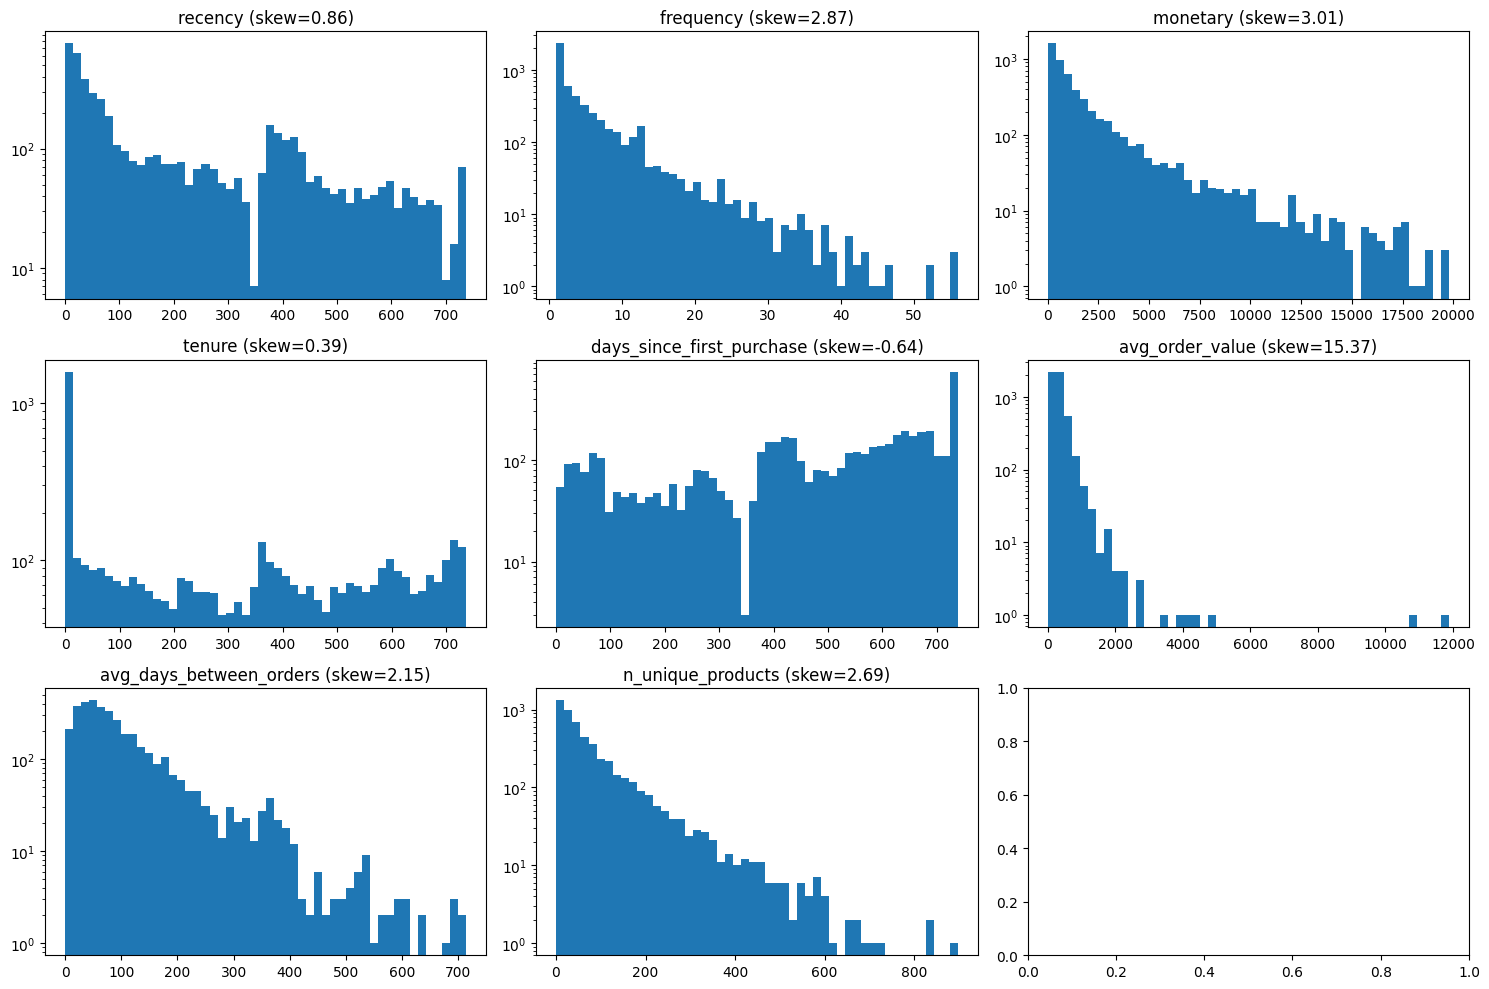

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(3, 3, figsize=(15, 10))
axes = axes.flatten()
cols = features.columns

for i, col in enumerate(cols):
    data = features[col].dropna()
    axes[i].hist(data, bins=50)
    axes[i].set_title(f'{col} (skew={data.skew():.2f})')
    axes[i].set_yscale('log')

plt.tight_layout()
plt.show()

**Skew values printed in each title.** A skew of 0 means symmetric; 
positive means right-tail; anything above 1 is strongly skewed; above 3 
is severe.

Most features show skew > 2, several above 5. Untransformed, K-Means 
would be dominated by a handful of extreme customers. The y-axis is 
log-scaled here just to keep the tall single-value bars from squashing 
everything else; the underlying data is on its native scale.

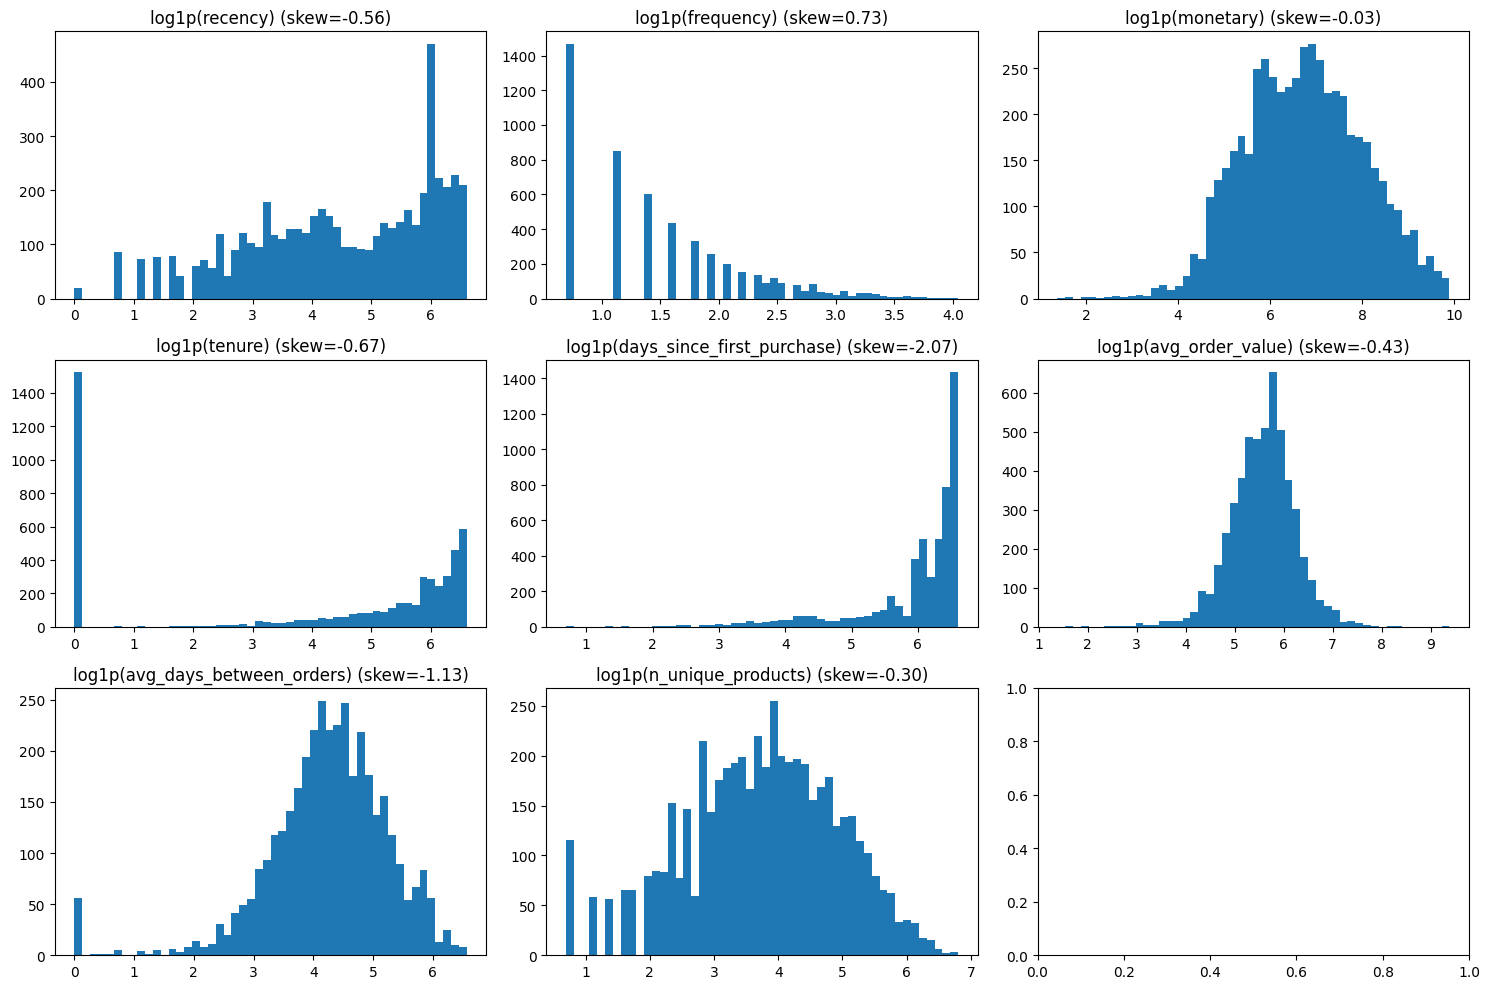

In [ ]:
fig, axes = plt.subplots(3, 3, figsize=(15, 10))
axes = axes.flatten()

for i, col in enumerate(cols):
    data = features[col].dropna()
    # log1p handles zeros safely; for recency we don't go negative
    data_log = np.log1p(data.clip(lower=0))
    axes[i].hist(data_log, bins=50)
    axes[i].set_title(f'log1p({col}) (skew={data_log.skew():.2f})')

plt.tight_layout()
plt.show()

**Reading the log-transformed distributions:**

After `log1p`, four features are approximately bell-shaped — 
clustering-ready in the canonical sense:

- monetary
- avg_order_value
- avg_days_between_orders
- n_unique_products

Four features remain non-bell-shaped, but for **meaningful reasons** 
rather than data problems:

- **recency** and **days_since_first_purchase** — both bounded by the 
  2-year data window. With a finite observation period, customers who 
  first appeared early accumulate at the high end. The distribution is 
  wide and flattish, not Gaussian.
- **frequency** — heavily mass at log1p(1) = 0.69, the 1,466 single-order 
  customers. A spike at the left, then a tail.
- **tenure** — same effect, magnified. Single-order customers have 
  tenure = 0 → log1p(0) = 0 → giant spike at zero.

**This is not a problem.** K-Means doesn't actually require Gaussian 
features — it requires *meaningful Euclidean distances*, which 
standardization gives us. Bell-shaped distributions are a bonus that 
tends to produce cleaner clusters; non-bell-shaped features can still 
be informative.

**For GMM, though, the non-Gaussian features will fit less neatly** — 
GMM explicitly assumes each component is roughly Gaussian. Worth 
noting as a known weakness of GMM on this data; it doesn't disqualify 
the method, but it explains why GMM may score lower than K-Means on 
silhouette later.

**Why `log1p` and not `log`?** `log(0)` is negative infinity; `log1p(0)` 
is 0 by definition (it computes `log(1+x)`). For non-negative features 
that can be zero — tenure for single-order customers, for instance — 
`log1p` is the safer choice.

In [ ]:
features.reset_index().to_parquet(
    "../data/processed/customer_features.parquet",
    index=False
)
print(f"Saved features for {len(features):,} customers.")

Saved features for 5,248 customers.


## 6 Check feature redundancy

Highly correlated features confuse clustering — they implicitly weight 
the same underlying signal twice. Before declaring the feature set 
final, check for high pairwise correlations (>0.85 is usually the 
threshold for "drop one").

In [ ]:
print(features[['recency', 'days_since_first_purchase']].corr())

                           recency  days_since_first_purchase
recency                    1.00000                    0.29702
days_since_first_purchase  0.29702                    1.00000


**Surprising result: correlation is only 0.30, not 0.7+ as one might expect.**

The two features measure different things:
- **recency** = how *recently* they bought (low = active, high = lapsed)
- **days_since_first_purchase** = how *long ago* they entered the system 
  (low = new customer, high = veteran)

A customer who first appeared 2 years ago and bought yesterday has 
high `days_since_first_purchase` but low `recency`. A customer who 
appeared 2 weeks ago and bought 2 weeks ago has low values for both. 
These are independent dimensions of customer lifecycle.

**Decision: keep both.** Each contributes distinct information that 
will help clustering distinguish "old loyal" from "old lapsed" from 
"new active" from "new lapsed."

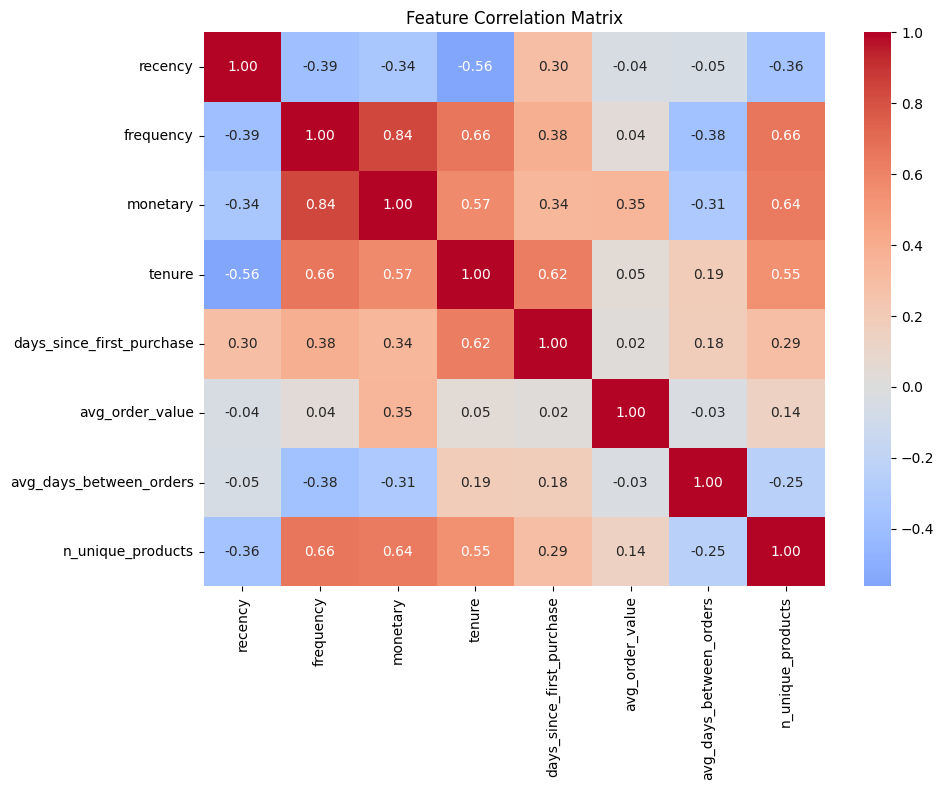

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))
sns.heatmap(features.corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Feature Correlation Matrix')
plt.tight_layout()
plt.show()

**Other notable correlations:**

- **frequency × monetary: 0.84** — high but not redundant. The 16% of 
  variance they don't share is captured by `avg_order_value`. In effect 
  we're representing the same underlying signal three ways (monetary, 
  frequency, AOV), which slightly weights it in clustering. Keeping all 
  three is the canonical RFM choice; it's what business stakeholders 
  expect to see.

No pair exceeds the 0.85 redundancy threshold, so we keep all 8 features 
as-is. The correlation matrix also confirms there's no surprise — every 
pair makes intuitive sense given what each feature measures.

**Note on weekend_purchase_ratio:** an earlier version of the feature 
engineering included a "weekend purchase ratio" feature. Investigation 
showed 63% of customers had zero weekend purchases (the retailer 
doesn't operate on Saturdays, leaving only Sunday for weekend activity). 
With most of the distribution at a single value, the feature provided 
little discriminative power and was dropped before this notebook was 
finalized — see the EDA notebook for the original finding.

## Feature Engineering Summary

Built **8 per-customer features** for 5,248 retail customers, aggregated 
from 624,590 transactions. Saved as `customer_features.parquet`.

### Snapshot date

**2011-12-10** (one day after the last transaction in the dataset).

### Feature inventory

| Feature | Type | Notes |
|---|---|---|
| `recency` | RFM | Days from last purchase to snapshot |
| `frequency` | RFM | Number of distinct invoices |
| `monetary` | RFM | Total lifetime revenue |
| `tenure` | Behavioral | Days from first to last purchase |
| `days_since_first_purchase` | Lifecycle | Customer "age" in the data window |
| `avg_order_value` | Behavioral | monetary / frequency |
| `avg_days_between_orders` | Behavioral | tenure / (frequency − 1); NaN for single-order |
| `n_unique_products` | Behavioral | Distinct StockCodes purchased |

### Distribution findings

- **All features highly right-skewed** raw (skew > 2 for most, > 5 for several)
- **After `log1p` transform**, four features become approximately Gaussian; 
  four others remain non-Gaussian for meaningful reasons (data-window 
  bounds, single-order customer spikes)
- **`log1p` chosen over `log`** to safely handle zero values (tenure = 0 
  for single-order customers)

### Single-order customers

**1,466 customers (27.9%)** have frequency = 1. They produce:
- NaN in `avg_days_between_orders` → impute during clustering prep
- Zero in `tenure` → expected; first == last purchase date
- A spike at the low end of `frequency` and `tenure` after log-transform

These customers are expected to form a distinct "one-time buyers" 
cluster — a real and marketable segment.

### Feature correlations

| Pair | r | Decision |
|---|---|---|
| recency × days_since_first_purchase | 0.30 | Keep both — measure different lifecycle dimensions |
| frequency × monetary | 0.84 | Keep both — high but expected for RFM |
| All others | < 0.85 | No removals needed |

### Decisions documented for the README

- **Dropped `weekend_purchase_ratio`** during development: 63% zero mass 
  made it non-discriminative (retailer doesn't operate Saturdays)
- **Single-order customer treatment** deferred to clustering step 
  (imputation strategy for `avg_days_between_orders`)
- **Final feature set is RFM-anchored** rather than including 
  product-category features (would require text clustering on 
  Descriptions — flagged as future work)

→ Proceed to notebook **04_clustering.ipynb**